# Visualization: Taylor Diagram (basic)

- Prepare input values.
- Plot basic Taylor Diagram as example.

**Hungjui Yu – 20260513**


In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [2]:
import numpy as np

import matplotlib.pyplot as plt
import geocat.viz as gv

***
## Visualization:

In [3]:
def lighten_color(rgb, factor=0.5):
    """Lighten the given RGB color by blending it with white.
    factor=0 returns white, factor=1 returns the original color.
    """
    return tuple((1 - factor) + factor * c for c in rgb)

In [4]:
color_1 = (213/255, 94/255, 0/255)    # Vermilion (Orange-Red)
color_2 = (0/255, 158/255, 115/255)   # Teal
color_3 = (86/255, 180/255, 233/255)  # Sky Blue
# color_3 = (0/255, 51/255, 128/255)    # Deep Indigo


### Taylor Diagram: 3 models:

In [17]:
ground_truth_std = 1.7

std_range_tuple = (0, 5)
std_val_list = np.arange(0, 5, 0.5)


prediction_std = [1.4, 1.6, 1.8]
prediction_corr = [0.2, 0.4, 0.7]


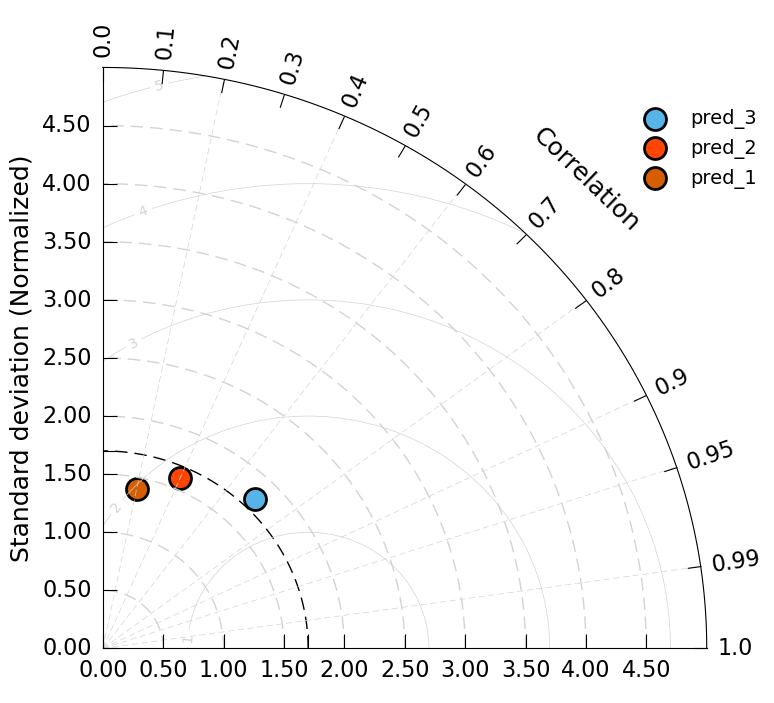

In [18]:
## Create basic figure and Taylor Diagram instance:
fig = plt.figure(figsize=(8, 8))

taylor = gv.TaylorDiagram( refstd=ground_truth_std
                         , fig=fig
                         , label=''
                         , std_range=std_range_tuple
                         , std_level=np.insert(std_val_list, np.searchsorted(std_val_list, ground_truth_std), ground_truth_std)
                         )
ax = plt.gca()

## Draw diagonal dashed lines from origin to correlation values
## Also enforces proper X-Y ratio
taylor.add_xgrid(np.array([0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99]))
taylor.add_ygrid(std_val_list)

taylor.add_model_set( [prediction_std[0]]
                    , [prediction_corr[0]]
                    , label='pred_1'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_1
                    , marker='o'
                    , facecolors=color_1
                    , edgecolors='k'
                    , linewidth=2
                    , s=250
                    )

taylor.add_model_set( [prediction_std[1]]
                    , [prediction_corr[1]]
                    , label='pred_2'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_1
                    , marker='o'
                    , facecolors='orangered'
                    , edgecolors='k'
                    , linewidth=2
                    # , linestyle='--'
                    , s=250
                    )

taylor.add_model_set( [prediction_std[2]]
                    , [prediction_corr[2]]
                    , label='pred_3'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_3
                    , marker='o'
                    , facecolors=color_3
                    , edgecolors='k'
                    , linewidth=2 
                    , s=250
                    )

#gv.util.set_axes_limits_and_ticks(ax, xlim=[0,2])

# taylor.add_model_name(['MLP', 'EBM', 'LR'], fontsize=16)

## Add figure title
# plt.title(f"{ana_year} {ana_yearmonth_range[0]}-{ana_yearmonth_range[1]} {wrf_sim_type} {sel_mode}", size=26, pad=45)

taylor.add_legend(fontsize=14)

## Add constant centered RMS difference contours.
crg = taylor.add_contours( levels=np.arange(0,10,1)
                         , colors='lightgrey'
                         , linewidths=0.5      
                         ).clabel()
# crg.clabel()

plt.savefig('fig.png', dpi=300, bbox_inches='tight')


NameError: name 'a' is not defined

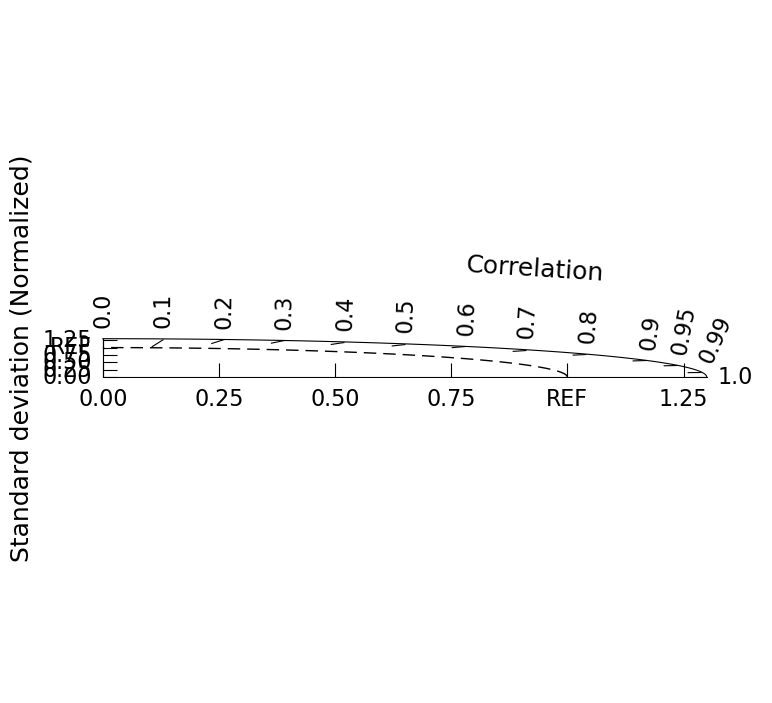

In [24]:
## Create basic figure and Taylor Diagram instance (normalized std.):
fig = plt.figure(figsize=(8, 8))

std_range_tuple = (0, 1.3)
std_val_list = np.arange(0, 5, 0.5)

taylor = gv.TaylorDiagram( # refstd=gt_std
                           fig=fig
                         , label='REF'
                         , std_range=std_range_tuple
                         # , std_level=np.insert(std_val_list, np.searchsorted(std_val_list, gt_std), gt_std)
                         )
ax = plt.gca()

## Draw diagonal dashed lines from origin to correlation values
## Also enforces proper X-Y ratio
taylor.add_xgrid(np.array([0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99]))
taylor.add_ygrid(np.arange(0,1.25,0.25))

taylor.add_model_set( prediction_std
                    , prediction_corr
                    , label='MLP\nclimate years'
                    , annotate_on=False
                    # , fontsize=0
                    # , xytext=(-5, 10)
                    , color='blue'#lighten_color(color_1, 0.8)
                    , marker='.'
                    # , facecolors=color_1
                    # , edgecolors='gray'
                    , alpha = 0.5
                    , linewidth=0
                    , s=50
                    # , zorder=5
                    )

#gv.util.set_axes_limits_and_ticks(ax, xlim=[0,2])

# taylor.add_model_name(['MLP', 'EBM', 'LR'], fontsize=16)

## Add figure title
# plt.title(f"{wrf_sim_type} {sel_mode}", size=26, pad=45)

tlg = taylor.add_legend(fontsize=16)
tlg.set_bbox_to_anchor((1.2, 1.05)) 

## Add constant centered RMS difference contours.
crg = taylor.add_contours( levels=np.arange(0,2,0.25)
                         , colors='lightgrey'
                         , linewidths=0.5      
                         ).clabel()
# crg.clabel()

# plt.savefig('fig.png', dpi=300, bbox_inches='tight')


### Taylor Diagram: climate years:

NameError: name 'a' is not defined

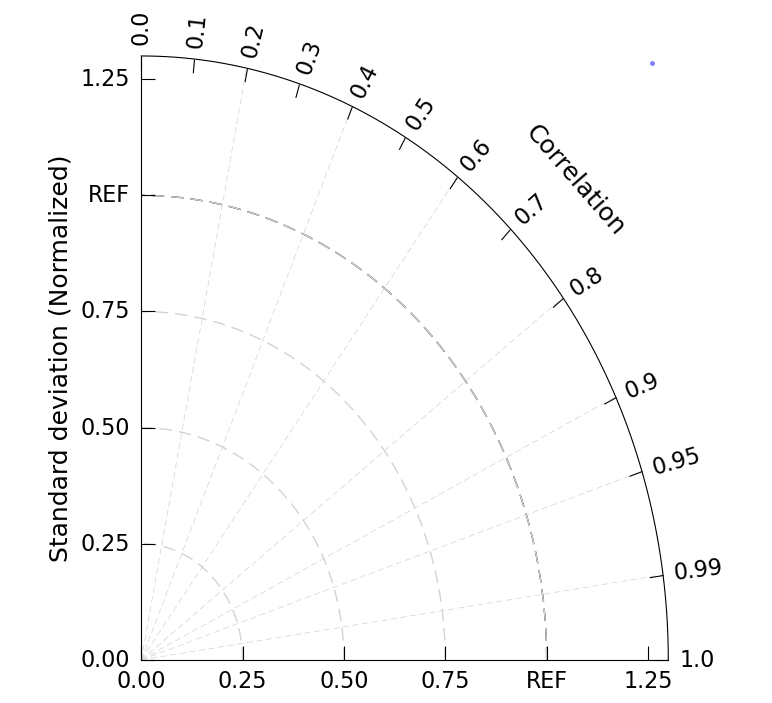

In [23]:
import geocat.viz as gv

## Create figure and Taylor Diagram instance:
fig = plt.figure(figsize=(8, 8))

std_range_tuple = (0, 1.3)
std_val_list = np.arange(0, 5, 0.5)

taylor = gv.TaylorDiagram( # refstd=gt_std
                           fig=fig
                         , label='REF'
                         , std_range=std_range_tuple
                         # , std_level=np.insert(std_val_list, np.searchsorted(std_val_list, gt_std), gt_std)
                         )
ax = plt.gca()

## Draw diagonal dashed lines from origin to correlation values
## Also enforces proper X-Y ratio
taylor.add_xgrid(np.array([0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99]))
taylor.add_ygrid(np.arange(0,1.25,0.25))


taylor.add_model_set( prediction_std
                    , prediction_corr
                    , label='MLP\nclimate years'
                    , annotate_on=False
                    # , fontsize=0
                    # , xytext=(-5, 10)
                    , color='blue'#lighten_color(color_1, 0.8)
                    , marker='.'
                    # , facecolors=color_1
                    # , edgecolors='gray'
                    , alpha = 0.5
                    , linewidth=0
                    , s=50
                    # , zorder=5
                    )

#gv.util.set_axes_limits_and_ticks(ax, xlim=[0,2])

# taylor.add_model_name(['MLP', 'EBM', 'LR'], fontsize=16)

## Add figure title
# plt.title(f"{wrf_sim_type} {sel_mode}", size=26, pad=45)

tlg = taylor.add_legend(fontsize=16)
tlg.set_bbox_to_anchor((1.2, 1.05)) 

## Add constant centered RMS difference contours.
crg = taylor.add_contours( levels=np.arange(0,2,0.25)
                         , colors='lightgrey'
                         , linewidths=0.5      
                         ).clabel()
# crg.clabel()

# plt.savefig('fig.png', dpi=300, bbox_inches='tight')


***
***
## <font color='teal'>Supplement:</font>
***
***

In [ ]:
import os
import sys
import time
import datetime as dt
import pytz
# from timezonefinder import TimezoneFinder
import glob
import numpy as np
import xarray as xr
import pandas as pd
import wrf
# import dask
from scipy import stats

# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

import joblib
import json

import cartopy.crs as ccrs
import cartopy.feature as cfeat
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import AutoMinorLocator, MaxNLocator, ScalarFormatter
import seaborn as sns

# mod_path = '/glade/work/hungjui/Research_work/MODULES/Plot_Map_CONUS'
# if mod_path not in sys.path:
#     sys.path.append(mod_path)
# import plot_map_CONUS1 as pmc

# mod_path = '/glade/work/hungjui/Research_work/ML_StormMode_Env_WRF/Model_Training_EBM_CoarseRes/'
# if mod_path not in sys.path:
#     sys.path.append(mod_path)
# import EBM_training_onemode_freq_rm0 as ebm_train_mod

# mod_path = '/glade/work/hungjui/Research_work/ML_StormMode_Env_WRF/Model_Training_NN_CoarseRes/'
# if mod_path not in sys.path:
#     sys.path.append(mod_path)
# import nn_regression_model
# import nn_regression_train

# mod_path = '/glade/work/hungjui/Research_work/ML_StormMode_Env_WRF/Eval_Model_NN_CoarseRes/'
# if mod_path not in sys.path:
#     sys.path.append(mod_path)
# import eval_NN as eval_nn


***
## Load saved prediction datasets:

### 3 models:

In [ ]:
## Load multiple prediction datasets:

sel_mode = 'freq_Conv'

wrf_sim_type = 'CTRL'

ana_year = '2022'
ana_yearmonth_range = ['01', '09']

path_prediction_data_1 = f'/glade/derecho/scratch/hungjui/DATA_prediction_NN_CoarseRes'
path_prediction_data_2 = f'/glade/derecho/scratch/hungjui/DATA_prediction_EBM_CoarseRes'
path_prediction_data_3 = f'/glade/derecho/scratch/hungjui/DATA_prediction_LR_CoarseRes'

prediction_1_name = f'021_NN_dur_2018_2021_freq_Conv_var16_rmAll90.0'
prediction_2_name = f'MergedEBM_2018_2021_freq_Conv_var16_rmAll90.0'
prediction_3_name = f'LR_dur_2018_2021_freq_Conv_var16_rmAll90.0'


ds_prediction_1 = xr.open_dataset(f'{path_prediction_data_1}/{prediction_1_name}_prediction_{wrf_sim_type}_{sel_mode}_{ana_year}.nc') 
ds_prediction_2 = xr.open_dataset(f'{path_prediction_data_2}/{prediction_2_name}_prediction_{wrf_sim_type}_{sel_mode}_{ana_year}.nc') 
ds_prediction_3 = xr.open_dataset(f'{path_prediction_data_3}/{prediction_3_name}_prediction_{wrf_sim_type}_{sel_mode}_{ana_year}.nc') 

da_prediction_1_avg = ds_prediction_1[f'predicted_{sel_mode}'].mean(dim='time') #.sel(time=slice('2022-06-01', '2022-09-30')).mean(dim='time')
da_prediction_2_avg = ds_prediction_2[f'predicted_{sel_mode}'].mean(dim='time') #.sel(time=slice('2022-06-01', '2022-09-30')).mean(dim='time')
da_prediction_3_avg = ds_prediction_3[f'predicted_{sel_mode}'].mean(dim='time') #.sel(time=slice('2022-06-01', '2022-09-30')).mean(dim='time')


### 100-km:

In [ ]:
## Load multiple prediction datasets:

sel_mode = 'freq_Conv'

wrf_sim_type = 'CTRL_100km'

ana_year = '2022'
ana_yearmonth_range = ['01', '09']

path_prediction_data_1 = f'/glade/derecho/scratch/hungjui/DATA_prediction_NN_CoarseRes/coarseres_100km'
# path_prediction_data_2 = f'/glade/derecho/scratch/hungjui/DATA_prediction_EBM_CoarseRes'
# path_prediction_data_3 = f'/glade/derecho/scratch/hungjui/DATA_prediction_LR_CoarseRes'

prediction_1_name = f'021_NN_dur_2018_2021_freq_Conv_var16_rmAll90.0'
# prediction_2_name = f'MergedEBM_2018_2021_freq_Conv_var16_rmAll90.0'
# prediction_3_name = f'LR_dur_2018_2021_freq_Conv_var16_rmAll90.0'


ds_prediction_1 = xr.open_dataset(f'{path_prediction_data_1}/{prediction_1_name}_prediction_{wrf_sim_type}_{sel_mode}_{ana_year}.nc') 
# ds_prediction_2 = xr.open_dataset(f'{path_prediction_data_2}/{prediction_2_name}_prediction_{wrf_sim_type}_{sel_mode}_{ana_year}.nc') 
# ds_prediction_3 = xr.open_dataset(f'{path_prediction_data_3}/{prediction_3_name}_prediction_{wrf_sim_type}_{sel_mode}_{ana_year}.nc') 

da_prediction_1_avg = ds_prediction_1[f'predicted_{sel_mode}'].mean(dim='time') #.sel(time=slice('2022-06-01', '2022-09-30')).mean(dim='time')
# da_prediction_2_avg = ds_prediction_2[f'predicted_{sel_mode}'].mean(dim='time') #.sel(time=slice('2022-06-01', '2022-09-30')).mean(dim='time')
# da_prediction_3_avg = ds_prediction_3[f'predicted_{sel_mode}'].mean(dim='time') #.sel(time=slice('2022-06-01', '2022-09-30')).mean(dim='time')


### Climate years:

In [ ]:
## Climate Years:

climate_years_list = [1982, 1988, 1993, 1997, 1998, 1999, 2005, 2011, 2012, 2013, 2014, 2015, 2018, 2019, 2020, 2021]
# climate_years_list = [2018, 2019, 2020, 2021]

path_prediction_data_climate = f'/glade/derecho/scratch/hungjui/DATA_prediction_NN_CoarseRes/climate_years'
path_prediction_data_training = f'/glade/derecho/scratch/hungjui/DATA_prediction_NN_CoarseRes/training_years'

ds_name_list = []

for climate_year in climate_years_list:
        if climate_year in [2018, 2019, 2020, 2021]:
                   ds_name_list.append(f'{path_prediction_data_training}/021_NN_dur_2018_2021_freq_Conv_var16_rmAll90.0_prediction_{wrf_sim_type}_{sel_mode}_{climate_year}.nc')
        else:
            ds_name_list.append(f'{path_prediction_data_climate}/021_NN_dur_2018_2021_freq_Conv_var16_rmAll90.0_prediction_{wrf_sim_type}_{sel_mode}_{climate_year}.nc')

print(ds_name_list)

***
## Load ground truth:

In [ ]:
ds_ground_truth = xr.open_dataset(f'/glade/derecho/scratch/hungjui/DATA_WRF_CONUS_404_SMode_v1.0/StormMode_Freq_CoarseRes_CTRL/wrf3d_404_{wrf_sim_type[0]}_freq_csmode_{ana_year}{ana_yearmonth_range[0]}_{ana_year}{ana_yearmonth_range[-1]}.nc')

da_ground_truth = ds_ground_truth[sel_mode]

ds_ground_truth.close()

da_ground_truth

In [ ]:
da_avg_ground_truth = ds_ground_truth[sel_mode].mean(dim='time')
# da_avg_ground_truth = ds_ground_truth[sel_mode].sel(time=slice('2022-01-01', '2022-05-31')).mean(dim='time')
# da_avg_ground_truth = ds_ground_truth[sel_mode].sel(time=slice('2022-06-01', '2022-09-30')).mean(dim='time')

da_avg_ground_truth

### 100-km:

In [ ]:
ds_ground_truth = xr.open_dataset(f'/glade/derecho/scratch/hungjui/DATA_WRF_CONUS_404_SMode_v1.0/StormMode_Freq_CoarseRes_CTRL_100km/wrf3d_404_{wrf_sim_type[0]}_freq_csmode_{ana_year}{ana_yearmonth_range[0]}_{ana_year}{ana_yearmonth_range[-1]}.nc')

***
## Calculation:

In [ ]:
## Bias metrics:

def calculate_mae(da, truth):
    # return (np.abs(da - truth).data).mean()
    return np.nanmean(np.abs(da - truth))

def calculate_rmse(da, truth):
    # return ((da - truth).data ** 2).mean() ** 0.5
    return np.sqrt(np.nanmean((da - truth) ** 2))

def calculate_centered_rmse_1(da, truth):
    da_centered = da - np.nanmean(da)
    truth_centered = truth - np.nanmean(truth)
    return np.sqrt(np.nanmean((da_centered - truth_centered) ** 2))

def calculate_centered_rmse_2(da, truth):
    diff = da - truth
    bias = np.nanmean(diff)
    return np.sqrt(np.nanmean((diff - bias) ** 2))

def calculate_bias(da, truth):
    # return ((da - truth).data).mean()
    return np.nanmean(da - truth)

def calculate_spatial_corr(da, truth):
    spatial_corr = xr.corr( da.stack(z=("south_north", "west_east"))
                          , truth.stack(z=("south_north", "west_east"))
                          , dim="z"
                          )
    return spatial_corr.data.mean()

def calculate_temporal_corr(da, truth):
    temporal_corr = xr.corr(da, truth, dim="time")
    return temporal_corr.mean().item()

def calculate_spatiotemporal_corr(da, truth):
    # Ensure alignment and flatten all dimensions
    da_flat = da.stack(all_dims=da.dims)
    truth_flat = truth.stack(all_dims=truth.dims)
    spatiotemporal_corr = xr.corr(da_flat, truth_flat, dim="all_dims")
    return spatiotemporal_corr.item()

def calculate_spatial_covariance(da, truth):
    da_stack = da.stack(z=("south_north", "west_east"))
    truth_stack = truth.stack(z=("south_north", "west_east"))
    return xr.cov(da_stack, truth_stack, dim="z").data.mean()

# def calculate_fss(ds, truth, threshold):
#     ds_binary = (ds >= threshold).astype(int)
#     truth_binary = (truth >= threshold).astype(int)
#     overlap = (ds_binary & truth_binary).sum(dim=["lat", "lon"])
#     total = (ds_binary | truth_binary).sum(dim=["lat", "lon"])
#     return (overlap / total).mean(dim="time")

def calculate_std(ds, truth):
    ds_std = ds.std(dim=["time","south_north", "west_east"])
    return ds_std.item()

def calculate_nstd(ds, truth):
    ds_std = ds.std(dim=["time","south_north", "west_east"])
    truth_std = truth.std(dim=["time", "south_north", "west_east"])
    return (ds_std / truth_std).item()
    

### Metrics: 3 models:

In [ ]:
start_time = time.time()

metrics = {
    "MAE": calculate_mae,
    "RMSE": calculate_rmse,
    "cRMSE1": calculate_centered_rmse_1,
    "cRMSE2": calculate_centered_rmse_2,
    "Bias": calculate_bias,
    "Mean Spatial Correlation": calculate_spatial_corr,
    "Mean Temporal Correlation": calculate_temporal_corr,
    "Mean Spatiotemporal Correlation": calculate_spatiotemporal_corr,
    "Mean Spatial Covariance": calculate_spatial_covariance,
    # "Fractional Skill Score (FSS)": lambda ds, truth: calculate_fss(ds, truth, threshold=50),
    "Standard Deviation (STD)": calculate_std,
    "Normalized Standard Deviation (NSTD)": calculate_nstd
}

# metrics_ds1 = {name: func(ds_prediction_1['predicted_freq_Conv'], ds_ground_truth['freq_Conv']) for name, func in metrics.items()}
# metrics_ds2 = {name: func(ds_prediction_2['predicted_freq_Conv'], ds_ground_truth['freq_Conv']) for name, func in metrics.items()}
# metrics_ds3 = {name: func(ds_prediction_3['predicted_freq_Conv'], ds_ground_truth['freq_Conv']) for name, func in metrics.items()}

metrics_ds1 = {name: func(ds_prediction_1['predicted_freq_Conv'].sel(time=slice(f"2022-05-01", None)), ds_ground_truth['freq_Conv'].sel(time=slice(f"2022-05-01", None))) for name, func in metrics.items()}
metrics_ds2 = {name: func(ds_prediction_2['predicted_freq_Conv'].sel(time=slice(f"2022-05-01", None)), ds_ground_truth['freq_Conv'].sel(time=slice(f"2022-05-01", None))) for name, func in metrics.items()}
metrics_ds3 = {name: func(ds_prediction_3['predicted_freq_Conv'].sel(time=slice(f"2022-05-01", None)), ds_ground_truth['freq_Conv'].sel(time=slice(f"2022-05-01", None))) for name, func in metrics.items()}

print(metrics_ds1)
print(metrics_ds2)
print(metrics_ds3)

end_time = time.time()
print(f"\nFinish in {end_time - start_time} sec.")


In [ ]:
metrics_df = pd.DataFrame([metrics_ds1, metrics_ds2, metrics_ds3])
metrics_df.index = ['MLP', 'EBM', 'LR'] 

metrics_df

In [ ]:
metrics_df.to_csv('/glade/derecho/scratch/hungjui/DATA_prediction_NN_CoarseRes/metrics/metrics_021_NN_dur_2018_2021_freq_Conv_var16_rmAll90.0_prediction_CTRL_freq_Conv_MLP_EBM_LR_2022_MJJAS.csv', index=False)

In [ ]:
# print(metrics_ds1['RMSE'], metrics_ds1['cRMSE1'], metrics_ds1['cRMSE2'])
# print(metrics_ds2['RMSE'], metrics_ds2['cRMSE1'], metrics_ds2['cRMSE2'])
# print(metrics_ds3['RMSE'], metrics_ds3['cRMSE1'], metrics_ds3['cRMSE2'])


In [ ]:
# print(np.nanmean(ds_ground_truth['freq_Conv']))
# print(np.nanmean(ds_prediction_1['predicted_freq_Conv']))
# print(np.nanmean(ds_prediction_2['predicted_freq_Conv']))
# print(np.nanmean(ds_prediction_3['predicted_freq_Conv']))

### Metrics: 100-km:

In [ ]:
start_time = time.time()

metrics = {
    "MAE": calculate_mae,
    "RMSE": calculate_rmse,
    "cRMSE1": calculate_centered_rmse_1,
    "cRMSE2": calculate_centered_rmse_2,
    "Bias": calculate_bias,
    "Mean Spatial Correlation": calculate_spatial_corr,
    "Mean Temporal Correlation": calculate_temporal_corr,
    "Mean Spatiotemporal Correlation": calculate_spatiotemporal_corr,
    "Mean Spatial Covariance": calculate_spatial_covariance,
    # "Fractional Skill Score (FSS)": lambda ds, truth: calculate_fss(ds, truth, threshold=50),
    "Standard Deviation (STD)": calculate_std,
    "Normalized Standard Deviation (NSTD)": calculate_nstd
}

# metrics_ds1 = {name: func(ds_prediction_1['predicted_freq_Conv'], ds_ground_truth['freq_Conv']) for name, func in metrics.items()}

metrics_ds1 = {name: func(ds_prediction_1['predicted_freq_Conv'].sel(time=slice(f"2022-05-01", None)), ds_ground_truth['freq_Conv'].sel(time=slice(f"2022-05-01", None))) for name, func in metrics.items()}

print(metrics_ds1)

end_time = time.time()
print(f"\nFinish in {end_time - start_time} sec.")


In [ ]:
metrics_df = pd.DataFrame([metrics_ds1])

metrics_df

In [ ]:
metrics_df.to_csv('/glade/derecho/scratch/hungjui/DATA_prediction_NN_CoarseRes/metrics/metrics_021_NN_dur_2018_2021_freq_Conv_var16_rmAll90.0_prediction_CTRL_freq_Conv_100km_2022_MJJAS.csv', index=False)

### Metrics: climate years:

In [ ]:
def load_ground_truth_by_year(yyyy_str, wrf_sim_type=wrf_sim_type, sel_mode=sel_mode):

    if yyyy_str == 2021:
        ds_ground_truth = xr.open_dataset(f'/glade/derecho/scratch/hungjui/DATA_WRF_CONUS_404_SMode_v1.0/StormMode_Freq_CoarseRes_{wrf_sim_type}/wrf3d_404_{wrf_sim_type[0]}_freq_csmode_{yyyy_str}01_{yyyy_str}09.nc')
    else:
        ds_ground_truth = xr.open_dataset(f'/glade/derecho/scratch/hungjui/DATA_WRF_CONUS_404_SMode_v1.0/StormMode_Freq_CoarseRes_{wrf_sim_type}/wrf3d_404_{wrf_sim_type[0]}_freq_csmode_{yyyy_str}01_{yyyy_str}12.nc')

    da_avg_ground_truth = ds_ground_truth[sel_mode].mean(dim='time')
    
    return ds_ground_truth, da_avg_ground_truth

In [ ]:

start_time = time.time()

metrics_climate_years = []

dataset_names = climate_years_list
print(dataset_names)

for ind, ds_name in enumerate(ds_name_list):

    print(ind)
    
    ## Load data:
    ds_prediction = xr.open_dataset(ds_name)
    da_prediction_avg = ds_prediction[f'predicted_{sel_mode}'].mean(dim='time')

    if wrf_sim_type == 'PGW':
        ds_ground_truth, da_avg_ground_truth = load_ground_truth_by_year(climate_years_list[ind])
    else:
        ds_ground_truth = xr.open_dataset(f'/glade/derecho/scratch/hungjui/DATA_WRF_CONUS_404_SMode_v1.0/StormMode_Freq_CoarseRes_{wrf_sim_type}/wrf3d_404_{wrf_sim_type[0]}_freq_csmode_{climate_years_list[ind]}01_{climate_years_list[ind]}12.nc')
        da_avg_ground_truth = ds_ground_truth[sel_mode].mean(dim='time')

    ## Calculation:
    metrics = { "MAE": calculate_mae,
                "RMSE": calculate_rmse,
                "cRMSE1": calculate_centered_rmse_1,
                "cRMSE2": calculate_centered_rmse_2,
                "Bias": calculate_bias,
                "Mean Spatial Correlation": calculate_spatial_corr,
                "Mean Temporal Correlation": calculate_temporal_corr,
                "Mean Spatiotemporal Correlation": calculate_spatiotemporal_corr,
                "Mean Spatial Covariance": calculate_spatial_covariance,
                # "Fractional Skill Score (FSS)": lambda ds, truth: calculate_fss(ds, truth, threshold=50),
                "Standard Deviation (STD)": calculate_std,
                "Normalized Standard Deviation (NSTD)": calculate_nstd
              }

    # metrics_pred ={name: func(ds_prediction[f'predicted_{sel_mode}'], ds_ground_truth[sel_mode]) for name, func in metrics.items()}
    metrics_pred = { "Models": dataset_names[ind]
                   , **{name: func(ds_prediction[f'predicted_{sel_mode}'], ds_ground_truth[sel_mode]) for name, func in metrics.items()}
                  }
    metrics_climate_years.append(metrics_pred)
    
    print(f'Complete process {ds_name}.')


end_time = time.time()
print(f"\nFinish in {end_time - start_time} sec.")


In [ ]:
metrics_df = pd.DataFrame(metrics_climate_years)
metrics_df

In [ ]:
metrics_df.to_csv('/glade/derecho/scratch/hungjui/DATA_prediction_NN_CoarseRes/metrics/metrics_021_NN_dur_2018_2021_freq_Conv_var16_rmAll90.0_prediction_CTRL_freq_Conv_climate_years.csv', index=False)

***
## Load saved metrics:

In [ ]:
df_metrics_3models = pd.read_csv("/glade/derecho/scratch/hungjui/DATA_prediction_NN_CoarseRes/metrics/metrics_021_NN_dur_2018_2021_freq_Conv_var16_rmAll90.0_prediction_CTRL_freq_Conv_MLP_EBM_LR.csv")

In [ ]:
df_metrics_3models_MJJAS = pd.read_csv("/glade/derecho/scratch/hungjui/DATA_prediction_NN_CoarseRes/metrics/metrics_021_NN_dur_2018_2021_freq_Conv_var16_rmAll90.0_prediction_CTRL_freq_Conv_MLP_EBM_LR_2022_MJJAS.csv")

In [ ]:
df_metrics_climate_years = pd.read_csv("/glade/derecho/scratch/hungjui/DATA_prediction_NN_CoarseRes/metrics/metrics_021_NN_dur_2018_2021_freq_Conv_var16_rmAll90.0_prediction_CTRL_freq_Conv_climate_years.csv")

In [ ]:
df_metrics_climate_years